# Notebook de obtención, limpieza y transformación de datos — Fase 2

**Proyecto transversal · MCDI500 Programación para la Ciencia de Datos**
**Magíster en Ciencia de Datos e Inteligencia Artificial · Universidad Andrés Bello**

**Grupo 5 — Factores asociados a la duración autorizada de los permisos de uso de vía
pública en San Francisco**

## Introducción

Este cuaderno toma el archivo original de permisos y deja un conjunto validado, listo para
modelar la duración autorizada en la Fase 3.

**Lo que recibe de la Fase 1.** `docs/diccionario_variables.csv` y `docs/metadatos_fase1.json`:
qué variable es el objetivo, cuáles son explicativas, cuáles están prohibidas por contener la
respuesta, y cuál agrupa la partición. Esta fase **no vuelve a decidirlo**; lo lee y se detiene
si no lo encuentra.

**Lo que entrega.** `data/processed/permisos_limpio.csv` —interpretable, para el análisis y los
gráficos de la Fase 4—, `data/processed/permisos_procesado.csv` —codificado y escalado, para el
modelado de la Fase 3—, los transformadores ajustados en `src/`, y los anexos del informe en
`docs/anexos/`.

> **Un principio gobierna el orden de los apartados.** La partición va **antes** de cualquier
> ajuste de imputador, codificador o escalador. Calcular una mediana, una moda o una escala
> sobre el conjunto completo filtra al conjunto de prueba información que no debería conocer.
> El orden no es estético: es la diferencia entre una evaluación honesta y una inflada.

### Librerías utilizadas

Cada importación responde a una necesidad concreta. `GroupShuffleSplit` particiona respetando
los grupos; `OneHotEncoder` codifica categorías sin inventar un orden; los tres escaladores se
comparan entre sí en el apartado 5 antes de elegir uno.

In [1]:
import io, contextlib                # capturar salidas para los anexos del informe
import json                          # contrato con la Fase 1 y metadatos
import pickle                        # persistir los transformadores ajustados
import sys
import warnings                      # tratar los avisos de parseo como evidencia
from datetime import date
from pathlib import Path

import numpy as np                   # cálculo numérico y enmascaramiento aleatorio
import pandas as pd                  # estructuras tabulares
import matplotlib.pyplot as plt      # gráficos de exploración y control

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import (OneHotEncoder, StandardScaler, MinMaxScaler,
                                   RobustScaler, LabelEncoder, OrdinalEncoder)

# Reproducibilidad: la misma semilla que el cuaderno de la Fase 1.
SEMILLA = 42
np.random.seed(SEMILLA)


def capturar(funcion, *args, **kwargs):
    """
    Ejecuta una funcion, muestra su salida en pantalla y ademas la devuelve como texto.

    Sirve para que los anexos del informe se generen desde la misma ejecucion que produce
    los resultados, en lugar de copiarse a mano desde una captura de pantalla.
    """
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        resultado = funcion(*args, **kwargs)
    texto = buffer.getvalue()
    print(texto, end="")
    return resultado, texto


print("Cuaderno de la Fase 2 ·", date.today().isoformat())

Cuaderno de la Fase 2 · 2026-09-16


## Configuración del entorno y de las rutas

Las rutas se resuelven igual que en la Fase 1: subiendo hasta encontrar un marcador de
repositorio, en lugar de suponer que la raíz coincide con el directorio desde el que se lanza
el cuaderno. Así ambos cuadernos escriben en el mismo árbol de archivos aunque vivan en
carpetas distintas.

In [2]:
MARCADORES = (".git", "requirements.txt", ".gitignore")


def localizar_raiz(inicio=None, marcadores=MARCADORES, niveles=5, respaldo=True):
    """Resuelve la raiz del proyecto. Identica a la de la Fase 1."""
    actual = Path(inicio or Path.cwd()).resolve()
    for candidata in [actual, *actual.parents][:niveles + 1]:
        if any((candidata / m).exists() for m in marcadores):
            return candidata, "estructurado"
    if respaldo:
        return actual, "plano"
    raise FileNotFoundError(f"No se encontro marcador de repositorio desde {actual}.")


RAIZ, MODO = localizar_raiz()
DIR_CRUDO = RAIZ / "data" / "raw"
DIR_PROCESADO = RAIZ / "data" / "processed"
DIR_DOCS = RAIZ / "docs"
DIR_SRC = RAIZ / "src"
DIR_ANEXOS = DIR_DOCS / "anexos"
for d in (DIR_PROCESADO, DIR_DOCS, DIR_SRC, DIR_ANEXOS):
    d.mkdir(parents=True, exist_ok=True)

# Modulo compartido, generado por el cuaderno de la Fase 1.
if str(DIR_SRC.resolve()) not in sys.path:
    sys.path.insert(0, str(DIR_SRC.resolve()))
try:
    import utilidades
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "No se encontro src/utilidades.py. Ejecute primero el cuaderno de la Fase 1."
    ) from e

print("Raíz del proyecto :", RAIZ)
print("Modo detectado    :", MODO)
print("Módulo importado  :", Path(utilidades.__file__).relative_to(RAIZ).as_posix())

Raíz del proyecto : /Users/ricardo/Desktop/Repositorios/proyecto-grupo5-mcdi500
Modo detectado    : estructurado
Módulo importado  : src/utilidades.py


### Procedencia del conjunto de datos y contrato con la Fase 1

La Fase 1 dejó escritas las decisiones sobre qué variable es el objetivo y cuáles no pueden
usarse para explicarla. Este cuaderno las lee. Si los artefactos no están, se detiene: es una
dependencia dura, no una sugerencia, porque sin el diccionario no se sabe qué variable contiene
la respuesta.

In [3]:
RUTA_DICC = utilidades.buscar_archivo("diccionario_variables.csv", RAIZ)
RUTA_META = utilidades.buscar_archivo("metadatos_fase1.json", RAIZ)

if RUTA_DICC is None or RUTA_META is None:
    raise FileNotFoundError(
        "Faltan los artefactos de la Fase 1. Ejecute S1_F1_Definicion.ipynb primero."
    )

DECLARADO = pd.read_csv(RUTA_DICC)                       # diccionario de la Fase 1
META_F1 = json.loads(Path(RUTA_META).read_text(encoding="utf-8"))

OBJETIVO     = META_F1["objetivo"]
EXPLICATIVAS = META_F1["explicativas"]
GRUPO_VAR    = META_F1["variable_grupo"]
PROHIBIDAS   = META_F1["prohibidas"]
INFORMATIVAS = META_F1["ausencia_informativa"]
FUENTE       = META_F1["fuente"]

print("Fuente   :", FUENTE["titulo"], f"({FUENTE['identificador']})")
print("Licencia :", FUENTE["licencia"])
print("Corte    :", FUENTE["corte_declarado"])
print("\nContrato leído de la Fase 1")
print(f"  objetivo             : {OBJETIVO}")
print(f"  explicativas ({len(EXPLICATIVAS)})     : {', '.join(EXPLICATIVAS)}")
print(f"  variable de grupo    : {GRUPO_VAR}")
print(f"  prohibidas           : {', '.join(PROHIBIDAS)}")
print(f"  ausencia informativa : {', '.join(INFORMATIVAS)}")

Fuente   : Active Street-Use Permits (x8nh-xzn6)
Licencia : Open Data Commons Public Domain Dedication and License (PDDL) 1.0
Corte    : 2026-09-09

Contrato leído de la Fase 1
  objetivo             : duracion_dias
  explicativas (11)     : tipo_permiso, analysis_neighborhood, agente, anio_aprobacion, distrito, n_segmentos, lag_aprob_inicio, mes_inicio, Permit Purpose, Inspector, permit_zipcode
  variable de grupo    : permit_number
  prohibidas           : Status, permit_start_date, permit_end_date
  ausencia informativa : Permit Purpose, Inspector


## 1. Obtención de los datos

La carga se encapsula en una función en lugar de una llamada suelta, por dos motivos: puede
probarse, y deja en un solo lugar la decisión de **leer todo como texto**.

Esa decisión es específica de esta fuente. Las coordenadas usan coma decimal y una parte de las
fechas admite dos lecturas, de modo que la inferencia automática de tipos puede acertar o
fallar según qué valor encuentre primero. Leer como texto obliga a declarar cada conversión, que
es lo que hace el apartado 3.

In [4]:
def cargar_datos(ruta, obligatorias=None):
    """
    Carga el archivo de permisos sin inferencia de tipos.

    Parametros
    ----------
    ruta : str | Path
        Archivo CSV a cargar.
    obligatorias : iterable of str | None
        Columnas que deben existir; si falta alguna se informa cual.

    Retorna
    -------
    pd.DataFrame
        Todas las columnas como texto.

    Lanza
    -----
    FileNotFoundError
        Si el archivo no existe.
    KeyError
        Si falta alguna columna obligatoria.
    """
    ruta = Path(ruta)
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontro el archivo {ruta}.")
    datos = pd.read_csv(ruta, dtype=str)
    if obligatorias:
        faltan = set(obligatorias) - set(datos.columns)
        if faltan:
            raise KeyError(f"Faltan columnas obligatorias: {sorted(faltan)}")
    return datos


ARCHIVO = utilidades.buscar_archivo(FUENTE["archivo"], RAIZ)
if ARCHIVO is None:
    raise FileNotFoundError(
        f"No se encontro {FUENTE['archivo']} en {DIR_CRUDO.relative_to(RAIZ).as_posix()}."
    )

df = cargar_datos(ARCHIVO, obligatorias=["permit_number", "permit_start_date",
                                         "permit_end_date", "Permit Type"])
df_crudo = df.copy(deep=True)          # referencia intacta para la validacion final

print("Archivo    :", ARCHIVO.relative_to(RAIZ).as_posix())
print("Dimensiones:", df.shape)

Archivo    : data/raw/Active_Street-Use_Permits_20260909.csv
Dimensiones: (6852, 29)


Mostramos las primeras filas para confirmar visualmente que las columnas se cargaron con el
nombre esperado. `head()` es la comprobación más barata que existe: si el separador o la
codificación fueran incorrectos, se vería aquí y no veinte celdas más abajo.

In [5]:
df.head()

,permit_number,streetname,Cross Street 1,Cross Street 2,Permit Type,Agent,AgentPhone,Permit Purpose,Approved Date,Status,...,Y,Latitude,Longitude,bpa,Location,the_geom,analysis_neighborhood,supervisor_district,data_as_of,data_loaded_at
0,26EXC-01641,08TH ST,NATOMA ST,HOWARD ST,Excavation,Ronan Construction Inc.,415-779-5262,"8th St, Clay St and Leavenworth St - Pavement ...",04/15/2026,APPROVED,...,"2110825,76329","37,77644115815","-122,4118820325",NaN,POINT (-122.41188203249555 37.77644115815177),POINT (-122.411882032 37.776441158),South of Market,6,2026/04/16 03:34:45 AM,2026/04/17 05:23:32 AM
1,25EXC-01889,SAN BRUNO AVE,MANSELL ST \ SALINAS AVE,ORDWAY ST,Excavation,"Cratus, Inc.",(415)939-2840,WD-2876 8-Inch Ductile Iron Water Main Repl...,07/18/2025,ACTIVE,...,"2090569,998","37,7209782871","-122,40087332838",NaN,POINT (-122.40087332838284 37.720978287099676),POINT (-122.400873328 37.720978287),Portola,10,2025/09/10 05:11:34 AM,2025/09/12 05:08:57 AM
2,23IE-00344,WALNUT ST,PACIFIC AVE,JACKSON ST,StrtImprov,"Partner's Contracting, Inc.",415-492-9233,Remove and reconstruct sidewalk and existing (...,08/26/2025,APPROVED,...,"2116443,35732","37,79125689282","-122,44945871865",202210184608,POINT (-122.44945871865453 37.79125689282032),POINT (-122.449458719 37.791256893),Presidio Heights,2,2025/08/28 03:42:52 AM,2025/08/29 05:13:53 AM
3,25EXC-01889,CAMPBELL AVE,SAN BRUNO AVE,BRUSSELS ST,Excavation,"Cratus, Inc.",(415)939-2840,WD-2876 8-Inch Ductile Iron Water Main Repl...,07/18/2025,ACTIVE,...,"2088480,85453","37,71525239967","-122,40007624052",NaN,POINT (-122.40007624051567 37.715252399671314),POINT (-122.400076241 37.7152524),Visitacion Valley,10,2025/09/10 05:11:34 AM,2025/09/12 05:08:57 AM
4,25EXC-01889,CANDLESTICK COVE WAY,EXECUTIVE PARK BLVD,NaN,Excavation,"Cratus, Inc.",(415)939-2840,WD-2876 8-Inch Ductile Iron Water Main Repl...,07/18/2025,ACTIVE,...,"2087023,572266","37,71134702909","-122,39401110729",NaN,POINT (-122.39401110729395 37.71134702909027),POINT (-122.394011107 37.711347029),Bayview Hunters Point,10,2025/09/10 05:11:34 AM,2025/09/12 05:08:57 AM


## 2. Exploración inicial

Antes de tocar nada, se mide. Esta sección no modifica el conjunto.

In [6]:
def explorar_dataframe(datos, nombre="conjunto"):
    """
    Resume dimensiones, tipos, faltantes y duplicados de un DataFrame.

    Retorna
    -------
    pd.DataFrame
        Perfil por columna, reutilizable como tabla del informe.
    """
    print(f"Exploración de {nombre}")
    print("-" * 45)
    print("Dimensiones          :", datos.shape)
    print("Duplicados exactos   :", int(datos.duplicated().sum()))
    print("Memoria aproximada   :", f"{datos.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    perfil = utilidades.perfilar(datos)
    con_nulos = int((perfil.n_nulos > 0).sum())
    print(f"Columnas con nulos   : {con_nulos} de {datos.shape[1]}")
    print(f"Máximo de nulos      : {perfil.pct_nulos.max():.2f}% "
          f"({perfil.pct_nulos.idxmax()})")
    return perfil


perfil_crudo = explorar_dataframe(df, "archivo tal como se descarga")
perfil_crudo

Exploración de archivo tal como se descarga
---------------------------------------------
Dimensiones          : (6852, 29)
Duplicados exactos   : 0
Memoria aproximada   : 13.0 MB
Columnas con nulos   : 16 de 29
Máximo de nulos      : 96.44% (CurbRampWork)


,rol,dtype,n_nulos,pct_nulos,n_unicos
permit_number,alta cardinalidad,object,0,0.00,2851
streetname,alta cardinalidad,object,0,0.00,932
Cross Street 1,alta cardinalidad,object,0,0.00,1424
Cross Street 2,alta cardinalidad,object,1000,14.59,1359
Permit Type,alta cardinalidad,object,0,0.00,26
Agent,alta cardinalidad,object,9,0.13,704
AgentPhone,alta cardinalidad,object,109,1.59,746
Permit Purpose,texto libre,object,1712,24.99,1454
Approved Date,fecha,object,18,0.26,1171
Status,binaria,object,0,0.00,2


También revisamos **cuántas categorías distintas** tiene cada variable de texto. La
cardinalidad decide el tratamiento: con pocos niveles se codifica directamente; con cientos hay
que agrupar antes, o la codificación produciría más columnas que filas útiles.

In [7]:
columnas_categoricas = ["Permit Type", "Status", "Agent", "Inspector",
                        "analysis_neighborhood", "supervisor_district", "permit_zipcode"]

cardinalidad = pd.DataFrame([
    {"variable": col,
     "niveles": int(df[col].nunique()),
     "pct_nulos": round(float(df[col].isna().mean() * 100), 2),
     "mas_frecuente": df[col].value_counts().index[0] if df[col].notna().any() else None,
     "cubre_top12_pct": round(float(df[col].value_counts(normalize=True).head(12).sum() * 100), 1)}
    for col in columnas_categoricas
])
print("Cardinalidad de las variables categóricas:\n")
display(cardinalidad)
print("Agent tiene cientos de niveles pero sus 12 principales cubren la mitad de las filas:")
print("por eso se agrupan en 12 + 'Otros' en lugar de codificarse una por una.")

Cardinalidad de las variables categóricas:



,variable,niveles,pct_nulos,mas_frecuente,cubre_top12_pct
0,Permit Type,26,0.00,Excavation,98.0
1,Status,2,0.00,APPROVED,100.0
2,Agent,704,0.13,"Esquivel Grading & Paving, Inc.",58.7
3,Inspector,60,36.56,Mario Novoa,65.6
4,analysis_neighborhood,41,0.04,Financial District/South Beach,57.6
5,supervisor_district,11,0.03,3,100.0
6,permit_zipcode,30,0.00,0,64.9


Agent tiene cientos de niveles pero sus 12 principales cubren la mitad de las filas:
por eso se agrupan en 12 + 'Otros' en lugar de codificarse una por una.


### Patrón de faltantes

Tres columnas superan el 60 % de valores ausentes, y ese es el primer criterio de descarte del
apartado siguiente. *(Figura del Anexo F.)*

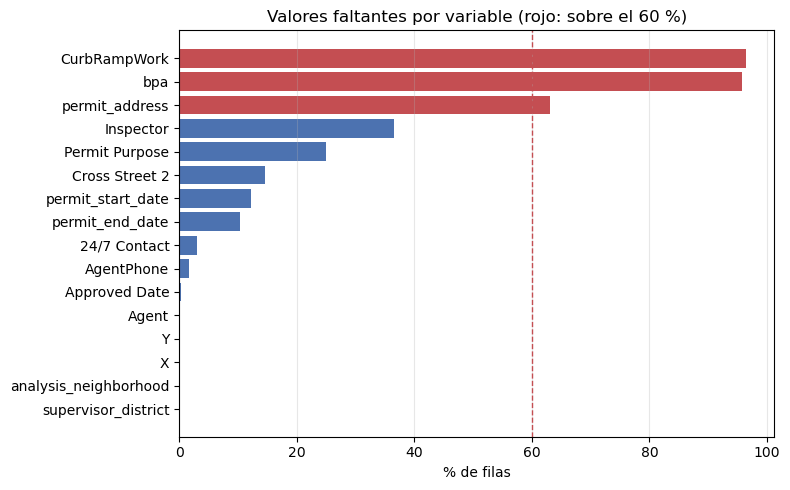

Sobre el 60 %: permit_address, bpa, CurbRampWork


In [8]:
nulos_pct = (df.isna().mean() * 100).loc[lambda s: s > 0].sort_values()

fig, eje = plt.subplots(figsize=(8, 5))
colores = ["#C44E52" if v > 60 else "#4C72B0" for v in nulos_pct.values]
eje.barh(nulos_pct.index, nulos_pct.values, color=colores)
eje.axvline(60, color="#C44E52", linestyle="--", linewidth=1)
eje.set_title("Valores faltantes por variable (rojo: sobre el 60 %)")
eje.set_xlabel("% de filas"); eje.grid(axis="x", alpha=.3)
plt.tight_layout()
fig.savefig(DIR_ANEXOS / "anexo_f3_patron_faltantes.png", dpi=150, bbox_inches="tight")
plt.show()

print("Sobre el 60 %:", ", ".join(nulos_pct[nulos_pct > 60].index))

### El diccionario de variables

La Fase 1 declaró el rol analítico y el **uso** de cada variable. Aquí se contrasta esa
declaración con lo que el archivo realmente trae: si alguien renombró una columna en el origen,
esta comprobación lo detecta antes de que el error se propague.

In [9]:
resumen_declarado = (DECLARADO.groupby(["uso", "rol_analitico"], observed=True)
                     .size().rename("variables").reset_index())
print("Lo que la Fase 1 declaró:\n")
display(resumen_declarado)

# Las variables derivadas todavia no existen en el crudo: se crean en el apartado 3.
presentes = [v for v in DECLARADO.variable if v in df.columns]
derivadas_pendientes = [v for v in DECLARADO.variable if v not in df.columns]
print(f"Declaradas que ya existen en el crudo : {len(presentes)}")
print(f"Declaradas que se derivan en el paso 3: {len(derivadas_pendientes)} -> "
      f"{', '.join(derivadas_pendientes)}")

Lo que la Fase 1 declaró:



,uso,rol_analitico,variables
0,contexto,alta cardinalidad,3
1,explicativa,alta cardinalidad,3
2,explicativa,discreta,4
3,explicativa,nominal,3
4,explicativa,texto libre,1
5,fuente_derivada,fecha,1
6,fuente_objetivo,fecha,2
7,grupo,alta cardinalidad,1
8,no_usada,binaria,1
9,objetivo,discreta,1


Declaradas que ya existen en el crudo : 15
Declaradas que se derivan en el paso 3: 8 -> duracion_dias, tipo_permiso, agente, anio_aprobacion, distrito, n_segmentos, lag_aprob_inicio, mes_inicio


### Valores atípicos: medir antes de decidir

La regla del rango intercuartílico marca observaciones alejadas del cuerpo de la distribución.
Marcar no es lo mismo que corregir: antes de eliminar nada hay que saber **qué** son esas
observaciones.

In [10]:
def detectar_atipicos_iqr(serie, factor=1.5):
    """
    Cuenta observaciones fuera del rango intercuartilico ampliado.

    Parametros
    ----------
    serie : pd.Series
        Valores numericos.
    factor : float
        Amplitud del rango. 1.5 es la convencion habitual.

    Retorna
    -------
    dict
        Limites, conteo y proporcion de atipicos.

    Lanza
    -----
    ValueError
        Si el factor no es positivo.
    """
    if factor <= 0:
        raise ValueError("El factor debe ser positivo.")
    s = serie.dropna()
    if s.empty:
        return {"inferior": None, "superior": None, "n": 0, "pct": 0.0}
    q1, q3 = s.quantile([.25, .75])
    ric = q3 - q1
    inferior, superior = q1 - factor * ric, q3 + factor * ric
    fuera = (s < inferior) | (s > superior)
    return {"inferior": round(float(inferior), 2), "superior": round(float(superior), 2),
            "n": int(fuera.sum()), "pct": round(float(fuera.mean() * 100), 2)}


# Se evalua sobre las coordenadas, unicas numericas del archivo sin derivar.
coordenadas = utilidades.convertir_tipos(df)[["Latitude", "Longitude"]]
tabla_atipicos = pd.DataFrame([
    {"variable": col, **detectar_atipicos_iqr(coordenadas[col])}
    for col in coordenadas.columns
])
display(tabla_atipicos)
print("Los atípicos de latitud y longitud corresponden a permisos en los extremos de la")
print("ciudad, no a errores de medición: ambos rangos caen dentro del recuadro de San")
print("Francisco. No se elimina ninguno. Las variables derivadas se examinan en el paso 3.")

,variable,inferior,superior,n,pct
0,Latitude,37.69,37.84,0,0.0
1,Longitude,-122.51,-122.35,0,0.0


Los atípicos de latitud y longitud corresponden a permisos en los extremos de la
ciudad, no a errores de medición: ambos rangos caen dentro del recuadro de San
Francisco. No se elimina ninguno. Las variables derivadas se examinan en el paso 3.


## 3. Limpieza de datos

Seis pasos, cada uno con su justificación y su cifra.

### 3.1 Conversión de tipos

Coordenadas con coma decimal y fechas con formato explícito. Cada conversión se verifica en el
momento.

In [11]:
for col in ["Latitude", "Longitude", "X", "Y"]:
    antes = pd.to_numeric(df[col], errors="coerce").notna().sum()
    despues = pd.to_numeric(df[col].str.replace(",", ".", regex=False),
                            errors="coerce").notna().sum()
    print(f"  {col:10} sin corregir: {antes:5} valores numéricos | corregida: {despues:5}")

df = utilidades.convertir_tipos(df)

print("\nFechas parseadas con format='%m/%d/%Y':")
for col in utilidades.COLS_FECHA:
    print(f"  {col:20} {df[col].notna().sum():5} valores, {df[col].isna().sum()} NaT, "
          f"rango {df[col].min():%Y-%m-%d} a {df[col].max():%Y-%m-%d}")

# Por que se declara el formato en lugar de deducirlo. La Fase 1 lo midio en detalle.
s = df_crudo.permit_start_date.dropna()
explicito = pd.to_datetime(s, format=utilidades.FORMATO_FECHA, errors="coerce")
invertido = pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")
ambiguas = int((explicito.notna() & invertido.notna()).sum())
with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always")
    inferido = pd.to_datetime(s, dayfirst=True, errors="coerce")
alterados = int((explicito.notna() & inferido.notna() & (explicito != inferido)).sum())

print(f"\n  Registros de permit_start_date legibles de las dos formas: {ambiguas} de {len(s)}"
      f" ({ambiguas/len(s):.1%})")
print(f"  El formato se deduce del primer valor de la columna, que aquí es {s.iloc[0]!r}")
print(f"  y es ambiguo. Al delegar esa detección se alteran {alterados} registros"
      f" ({alterados/len(s):.1%}) y la librería {'avisa' if avisos else 'NO avisa'} de ello.")

  Latitude   sin corregir:     0 valores numéricos | corregida:  6852
  Longitude  sin corregir:     0 valores numéricos | corregida:  6852
  X          sin corregir:     1 valores numéricos | corregida:  6844
  Y          sin corregir:     1 valores numéricos | corregida:  6844

Fechas parseadas con format='%m/%d/%Y':
  Approved Date         6834 valores, 18 NaT, rango 2000-02-07 a 2026-09-08
  permit_start_date     6017 valores, 835 NaT, rango 2015-04-22 a 2030-06-24
  permit_end_date       6141 valores, 711 NaT, rango 2019-06-15 a 2050-01-01

  Registros de permit_start_date legibles de las dos formas: 2473 de 6017 (41.1%)
  El formato se deduce del primer valor de la columna, que aquí es '05/01/2026'
  y es ambiguo. Al delegar esa detección se alteran 2257 registros (37.5%) y la librería NO avisa de ello.


### 3.2 Centinelas y coherencia temporal

Un centinela es un valor que parece dato pero significa «no hay dato». Aquí, el código postal
cero.

In [12]:
ceros = int((df_crudo.permit_zipcode == "0").sum())
print(f"permit_zipcode == '0' convertido a ausente: {ceros} filas ({ceros/len(df):.1%})")
print("Sin este paso, esos permisos quedarían con un código postal inexistente y el")
print("análisis territorial los trataría como un barrio más.\n")

print("Coherencia temporal")
print("  término anterior al inicio    :",
      int((df.permit_end_date < df.permit_start_date).sum()))
print("  término presente sin inicio   :",
      int((df.permit_start_date.isna() & df.permit_end_date.notna()).sum()))
retro = int((df["Approved Date"] > df.permit_start_date).sum())
print(f"  aprobación posterior al inicio: {retro} ({retro/len(df):.1%}) — anomalía a declarar")
print("\nLa tercera NO se corrige: alterar fechas oficiales para que encajen con una")
print("expectativa propia sería fabricar datos. Se conserva como lag_aprob_inicio, que")
print("toma valores negativos en esos casos, y se declara en el informe.")

permit_zipcode == '0' convertido a ausente: 819 filas (12.0%)
Sin este paso, esos permisos quedarían con un código postal inexistente y el
análisis territorial los trataría como un barrio más.

Coherencia temporal
  término anterior al inicio    : 0
  término presente sin inicio   : 127
  aprobación posterior al inicio: 1320 (19.3%) — anomalía a declarar

La tercera NO se corrige: alterar fechas oficiales para que encajen con una
expectativa propia sería fabricar datos. Se conserva como lag_aprob_inicio, que
toma valores negativos en esos casos, y se declara en el informe.


### 3.3 Descarte de columnas

Catorce columnas, por cuatro motivos: exceso de faltantes, varianza nula, redundancia
geométrica y ausencia de valor explicativo. El motivo de cada una vive en
`utilidades.DESCARTES`, de modo que el criterio esté en un solo lugar y no se pierda.

In [13]:
motivos = pd.DataFrame([
    {"columna": col,
     "pct_nulos": round(float(df_crudo[col].isna().mean() * 100), 2),
     "n_unicos": int(df_crudo[col].nunique()),
     "motivo": motivo}
    for col, motivo in utilidades.DESCARTES.items() if col in df_crudo.columns
]).sort_values("pct_nulos", ascending=False)

motivos.to_csv(DIR_DOCS / "columnas_descartadas.csv", index=False, encoding="utf-8")
display(motivos)
print(f"CurbRampWork merece una nota: además del 96,4 % de nulos, tiene un único valor "
      f"distinto ({df_crudo.CurbRampWork.dropna().unique().tolist()}).")
print("Una variable sin variación no puede explicar nada, aunque estuviera completa.")

,columna,pct_nulos,n_unicos,motivo
0,CurbRampWork,96.44,1,"96,4% de nulos y un unico valor distinto: vari..."
1,bpa,95.67,215,"95,7% de nulos"
2,permit_address,63.06,1997,"63,1% de nulos; redundante con streetname y cr..."
12,24/7 Contact,2.95,421,"dato de contacto, sin valor analitico"
11,AgentPhone,1.59,746,"dato de contacto, sin valor analitico"
9,Agent,0.13,704,reemplazada por agente agrupado
5,X,0.12,5750,mismo punto en California State Plane; redundante
6,Y,0.12,5748,mismo punto en California State Plane; redundante
10,supervisor_district,0.03,11,reemplazada por distrito como categorica
3,Location,0.00,5758,"geometria en texto, redundante con Latitude y ..."


CurbRampWork merece una nota: además del 96,4 % de nulos, tiene un único valor distinto (['true']).
Una variable sin variación no puede explicar nada, aunque estuviera completa.


### 3.4 Derivación de variables

El objetivo y las variables explicativas de la pregunta, más tres derivadas que capturan tamaño
del proyecto, retraso administrativo y estacionalidad.

In [14]:
df = utilidades.derivar_variables(df)
df = df.drop(columns=[col for col in utilidades.DESCARTES if col in df.columns])

DERIVADAS = ["duracion_dias", "n_segmentos", "lag_aprob_inicio", "anio_aprobacion",
             "mes_inicio", "tipo_permiso", "agente", "distrito"]
print("Derivadas:", ", ".join(DERIVADAS))
print(f"\ntipo_permiso: {df.tipo_permiso.nunique()} niveles "
      f"(desde {df_crudo['Permit Type'].nunique()})")
print(f"agente      : {df.agente.nunique()} niveles (desde {df_crudo['Agent'].nunique()})")
print(f"n_segmentos : mediana {df.n_segmentos.median():.0f}, máximo {df.n_segmentos.max()}")
print(f"lag_aprob_inicio: mediana {df.lag_aprob_inicio.median():.0f} días, "
      f"{int((df.lag_aprob_inicio < 0).sum())} negativos")

# Los atipicos de las derivadas, ahora que existen.
tabla_atipicos_derivadas = pd.DataFrame([
    {"variable": col, **detectar_atipicos_iqr(df[col])}
    for col in ["duracion_dias", "n_segmentos", "lag_aprob_inicio"]
])
display(tabla_atipicos_derivadas)
print("No se elimina ninguno: son permisos reales de larga duración y obras que abarcan")
print("muchos tramos. Eliminarlos borraría justamente lo que el proyecto quiere explicar.")

Derivadas: duracion_dias, n_segmentos, lag_aprob_inicio, anio_aprobacion, mes_inicio, tipo_permiso, agente, distrito

tipo_permiso: 13 niveles (desde 26)
agente      : 13 niveles (desde 704)
n_segmentos : mediana 12, máximo 205
lag_aprob_inicio: mediana 4 días, 1320 negativos


,variable,inferior,superior,n,pct
0,duracion_dias,-950.0,1826.0,1163,19.34
1,n_segmentos,-110.0,186.0,205,2.99
2,lag_aprob_inicio,-13.5,22.5,1565,26.03


No se elimina ninguno: son permisos reales de larga duración y obras que abarcan
muchos tramos. Eliminarlos borraría justamente lo que el proyecto quiere explicar.


### 3.5 Filtro de filas y duplicados

Solo se conservan los permisos con ambas fechas presentes: sin ellas la duración autorizada no
existe.

> *Enfoque descartado:* imputar las fechas ausentes para conservar los 6.852 registros. Imputar
> la variable objetivo fabrica los casos que después se pretende explicar.

In [15]:
antes = len(df)
df = df.dropna(subset=[OBJETIVO])
sin_objetivo = antes - len(df)

dups = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

print(f"Filas iniciales                       : {antes}")
print(f"Descartadas por falta de fecha        : {sin_objetivo}")
print(f"Duplicados exactos tras los descartes : {dups}")
print(f"Conjunto limpio                       : {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Permisos únicos                       : {df[GRUPO_VAR].nunique()}")

Filas iniciales                       : 6852
Descartadas por falta de fecha        : 838
Duplicados exactos tras los descartes : 4
Conjunto limpio                       : 6010 filas x 23 columnas
Permisos únicos                       : 2139


### 3.6 Contraste con el módulo compartido

La Fase 1 dejó en `src/utilidades.py` una función que hace toda esta limpieza de una sola vez.
Este cuaderno acaba de hacerla paso a paso y a la vista. Los dos caminos deben llegar al mismo
sitio; si no, hay un error en alguno de los dos y conviene saberlo ahora.

> Es el mismo principio que aplicar dos personas la misma suma por separado y comparar el total.

In [16]:
referencia = utilidades.construir_conjunto_trabajo(df_crudo)

assert df.shape == referencia.shape, f"Dimensiones distintas: {df.shape} vs {referencia.shape}"
assert set(df.columns) == set(referencia.columns), "Conjuntos de columnas distintos"
pd.testing.assert_frame_equal(
    df.sort_index(axis=1).reset_index(drop=True),
    referencia.sort_index(axis=1).reset_index(drop=True),
    check_dtype=False,
)
print("[OK] El pipeline paso a paso y construir_conjunto_trabajo() producen el mismo conjunto")
print(f"     {df.shape[0]} filas x {df.shape[1]} columnas")

[OK] El pipeline paso a paso y construir_conjunto_trabajo() producen el mismo conjunto
     6010 filas x 23 columnas


### 3.7 La partición va antes de imputar

**Aquí el cuaderno se aparta de la guía por una razón importante.** La guía advierte del
riesgo de fuga al calcular el valor de relleno sobre todo el conjunto, pero no lo evita. Este
cuaderno sí: la partición se hace **antes** de ajustar cualquier transformador, y todos se
ajustan únicamente con la parte de entrenamiento.

**Y cómo se parte también importa.** Un mismo permiso cubre hasta 205 tramos de calle que
comparten agente, tipo y **las dos fechas**, es decir, comparten el valor del objetivo. Si unos
tramos van a entrenamiento y otros a prueba, la evaluación mide memorización en lugar de
generalización. Por eso se agrupa por permiso.

In [17]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEMILLA)
idx_tr, idx_te = next(gss.split(df, groups=df[GRUPO_VAR]))

df["particion"] = "train"
df.loc[df.index[idx_te], "particion"] = "test"
es_train = df.particion.eq("train")

permisos_tr = set(df.loc[es_train, GRUPO_VAR])
permisos_te = set(df.loc[~es_train, GRUPO_VAR])

print(f"Entrenamiento: {es_train.sum():5} filas | {len(permisos_tr)} permisos")
print(f"Prueba       : {(~es_train).sum():5} filas | {len(permisos_te)} permisos")
print(f"\nDuración mediana  train: {df.loc[es_train, OBJETIVO].median():.0f} días")
print(f"Duración mediana  test : {df.loc[~es_train, OBJETIVO].median():.0f} días")

assert not permisos_tr & permisos_te, "Un permiso no puede estar en ambas particiones"
print("\n[OK] Sin solapamiento de permisos entre particiones")

Entrenamiento:  4435 filas | 1604 permisos
Prueba       :  1575 filas | 535 permisos

Duración mediana  train: 487 días
Duración mediana  test : 386 días

[OK] Sin solapamiento de permisos entre particiones


### 3.8 Tratamiento de la ausencia: dos regímenes, no uno

La Fase 1 midió que en esta fuente la ausencia **no es homogénea**. En dos variables se asocia a
permisos mucho más largos; en otras dos no distingue nada. Eso obliga a dos tratamientos
distintos, y la decisión se toma con cifras.

In [18]:
ausencia = pd.DataFrame([
    {"variable": col,
     "pct_ausente": round(float(df[col].isna().mean() * 100), 1),
     "mediana_presente": round(float(df.loc[df[col].notna(), OBJETIVO].median())),
     "mediana_ausente": round(float(df.loc[df[col].isna(), OBJETIVO].median())),
     "razon": round(float(df.loc[df[col].isna(), OBJETIVO].median()
                          / df.loc[df[col].notna(), OBJETIVO].median()), 2),
     "tratamiento": "categoría explícita" if col in INFORMATIVAS else "imputación"}
    for col in ["Permit Purpose", "Inspector", "Cross Street 2", "permit_zipcode"]
])
display(ausencia)
print("En Permit Purpose la ausencia multiplica por casi nueve la duración mediana.")
print("Imputar ese hueco destruiría información real sobre el proceso administrativo.")

,variable,pct_ausente,mediana_presente,mediana_ausente,razon,tratamiento
0,Permit Purpose,26.3,452,3934,8.70,categoría explícita
1,Inspector,38.5,459,675,1.47,categoría explícita
2,Cross Street 2,16.0,478,521,1.09,imputación
3,permit_zipcode,13.6,478,487,1.02,imputación


En Permit Purpose la ausencia multiplica por casi nueve la duración mediana.
Imputar ese hueco destruiría información real sobre el proceso administrativo.


**Ausencia informativa: se codifica, no se imputa.** `Permit Purpose` es texto libre y no
entra al modelo como tal; se convierte en dos variables que sí son utilizables y que preservan
la señal de su ausencia. `Inspector` conserva «Sin asignar» como nivel propio.

Es el mismo recurso que la guía emplea con el indicador de valor imputado, llevado un paso más
allá: aquí la ausencia no solo se marca, se usa.

In [19]:
df["tiene_proposito"] = df["Permit Purpose"].notna().astype(int)
df["largo_proposito"] = df["Permit Purpose"].fillna("").str.len()

principales_insp = df.Inspector.value_counts().head(12).index
df["inspector"] = np.where(df.Inspector.isna(), "Sin asignar",
                           np.where(df.Inspector.isin(principales_insp),
                                    df.Inspector, "Otros"))

print("tiene_proposito :", df.tiene_proposito.value_counts().to_dict())
print("largo_proposito : mediana", int(df.largo_proposito.median()),
      "| máximo", int(df.largo_proposito.max()))
print("inspector       :", df.inspector.nunique(), "niveles;",
      f"'Sin asignar' cubre {(df.inspector == 'Sin asignar').mean():.1%} de las filas")
print("\nDuración mediana por presencia de propósito:")
print(df.groupby("tiene_proposito")[OBJETIVO].median().round(0).to_string())
print("\nLa señal que la ausencia contenía queda ahora dentro del conjunto, como variable.")

tiene_proposito : {1: 4429, 0: 1581}
largo_proposito : mediana 43 | máximo 791
inspector       : 14 niveles; 'Sin asignar' cubre 38.5% de las filas

Duración mediana por presencia de propósito:
tiene_proposito
0    3934.0
1     452.0

La señal que la ausencia contenía queda ahora dentro del conjunto, como variable.


### 3.9 Comparar los métodos antes de elegir

Para las dos variables cuya ausencia no informa hay que elegir una estrategia de relleno, y la
elección se mide en lugar de opinarse.

**Cómo se mide algo que no se conoce.** Se toman valores que **sí** están, se oculta el 10 % al
azar, se intenta reconstruirlos y se compara con el valor real que se había ocultado. Como la
verdad se conoce por construcción, se sabe exactamente cuánto acierta cada método.

Todo el procedimiento se ejecuta **solo sobre la partición de entrenamiento**.

In [20]:
def comparar_imputaciones(datos, columnas, agrupador="tipo_permiso",
                          fraccion=0.10, semilla=SEMILLA):
    """
    Enmascara valores observados y mide el acierto de cada estrategia de imputacion.

    Parametros
    ----------
    datos : pd.DataFrame
        Particion de entrenamiento.
    columnas : list of str
        Variables categoricas a evaluar.
    agrupador : str
        Variable de agrupacion para la estrategia condicionada.
    fraccion : float
        Proporcion de valores observados que se oculta, entre 0 y 1.

    Retorna
    -------
    pd.DataFrame
        Acierto exacto por columna y estrategia.

    Lanza
    -----
    ValueError
        Si la fraccion esta fuera del intervalo (0, 1).
    KeyError
        Si alguna columna no existe.
    """
    if not 0 < fraccion < 1:
        raise ValueError("fraccion debe estar entre 0 y 1")
    faltan = set(list(columnas) + [agrupador]) - set(datos.columns)
    if faltan:
        raise KeyError(f"Columnas ausentes: {sorted(faltan)}")

    generador = np.random.default_rng(semilla)
    resultados = []
    for col in columnas:
        observados = datos.index[datos[col].notna()]
        ocultos = generador.choice(observados, size=int(len(observados) * fraccion),
                                   replace=False)
        verdad = datos.loc[ocultos, col]
        d = datos.copy()
        d.loc[ocultos, col] = np.nan

        moda_global = d[col].mode()
        moda_global = moda_global.iloc[0] if len(moda_global) else "Desconocido"
        por_grupo = d.groupby(agrupador)[col].transform(
            lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan)

        estrategias = {
            "moda global": d[col].fillna(moda_global),
            f"moda por {agrupador}": d[col].fillna(por_grupo).fillna(moda_global),
            "categoría 'Desconocido'": d[col].fillna("Desconocido"),
        }
        for nombre, imputado in estrategias.items():
            resultados.append({"variable": col, "estrategia": nombre,
                               "acierto": round(float((imputado.loc[ocultos] == verdad).mean()), 4)})
    return pd.DataFrame(resultados).pivot(index="variable", columns="estrategia",
                                          values="acierto")


train = df.loc[es_train]
comparacion_imp = comparar_imputaciones(train, ["permit_zipcode", "Cross Street 2"])
adivinan = ["moda global", "moda por tipo_permiso"]
comparacion_imp["% erróneos si se adivina"] = (
    (1 - comparacion_imp[adivinan].max(axis=1)) * 100).round(1)
print("Proporción de valores recuperados exactamente, con el 10 % enmascarado.")
print("La columna 'categoría Desconocido' vale 0 POR CONSTRUCCIÓN: esa estrategia no")
print("intenta adivinar, así que nunca acierta un valor enmascarado. No compite en el")
print("mismo eje; la cifra que decide es la última columna.\n")
comparacion_imp

Proporción de valores recuperados exactamente, con el 10 % enmascarado.
La columna 'categoría Desconocido' vale 0 POR CONSTRUCCIÓN: esa estrategia no
intenta adivinar, así que nunca acierta un valor enmascarado. No compite en el
mismo eje; la cifra que decide es la última columna.



estrategia,categoría 'Desconocido',moda global,moda por tipo_permiso,% erróneos si se adivina
variable,,,,
Cross Street 2,0.0,0.0054,0.0080,99.2
permit_zipcode,0.0,0.0601,0.1044,89.6


**Decisión.** Las dos estrategias que adivinan fallan casi siempre: la mejor se equivoca en el
**99,2 %** de los valores de `Cross Street 2` y en el **89,6 %** de los de `permit_zipcode`. Y eso
es en sí un resultado: `Cross Street 2` identifica una calle transversal concreta —alrededor de
1.300 valores distintos— y deducirla del tipo de permiso no tiene sentido físico.

Se adopta la **categoría explícita `Desconocido`**, que nunca es falsa. Para `lag_aprob_inicio` y `anio_aprobacion`, numéricas y con muy
poca ausencia, se usa la mediana de entrenamiento.

> *Enfoque descartado:* eliminar las filas con estas variables ausentes. Serían 961 y 817
> registros sobre 6.010; descartar alrededor del 13 % de los casos para evitar una etiqueta es
> una mala permuta.

In [21]:
class ImputadorMixto:
    """
    Imputa categoricas con una etiqueta explicita y numericas con la mediana.

    Se ajusta solo con la particion de entrenamiento. Sigue la interfaz fit/transform de
    scikit-learn para poder encadenarse en la Fase 3 sin reajustarse.
    """

    def __init__(self, categoricas, numericas, etiqueta="Desconocido"):
        self.categoricas = list(categoricas)
        self.numericas = list(numericas)
        self.etiqueta = etiqueta
        self.medianas_ = {}
        self.ajustado_ = False

    def fit(self, datos):
        faltan = set(self.categoricas + self.numericas) - set(datos.columns)
        if faltan:
            raise KeyError(f"Columnas ausentes: {sorted(faltan)}")
        self.medianas_ = {c: float(datos[c].median()) for c in self.numericas}
        self.ajustado_ = True
        return self

    def transform(self, datos):
        if not self.ajustado_:
            raise RuntimeError("Llame a fit antes de transform.")
        d = datos.copy()
        for col in self.categoricas:
            d[col] = d[col].fillna(self.etiqueta)
        for col in self.numericas:
            d[col] = d[col].fillna(self.medianas_[col])
        return d

    def fit_transform(self, datos):
        return self.fit(datos).transform(datos)


CATEGORICAS_IMPUTAR = ["permit_zipcode", "Cross Street 2", "analysis_neighborhood"]
NUMERICAS_IMPUTAR = ["lag_aprob_inicio", "anio_aprobacion"]

imputador = ImputadorMixto(CATEGORICAS_IMPUTAR, NUMERICAS_IMPUTAR)
imputador.fit(df.loc[es_train])          # AJUSTE SOLO EN ENTRENAMIENTO
df = imputador.transform(df)

restantes = int(df[CATEGORICAS_IMPUTAR + NUMERICAS_IMPUTAR].isna().sum().sum())
print("Medianas aprendidas en entrenamiento:",
      {k: round(v, 1) for k, v in imputador.medianas_.items()})
print("Nulos restantes en las columnas tratadas:", restantes)
assert restantes == 0

Medianas aprendidas en entrenamiento: {'lag_aprob_inicio': 3.0, 'anio_aprobacion': 2026.0}
Nulos restantes en las columnas tratadas: 0


## 4. Transformación: codificación One-Hot

### El patrón `fit` / `transform`

Un codificador **aprende** en `fit` qué categorías existen y **aplica** en `transform` esa misma
correspondencia. Separar ambos pasos es lo que permite que el conjunto de prueba se codifique
con las categorías aprendidas en entrenamiento, y no con las suyas propias.

**No se usa `LabelEncoder`.** Está diseñado para la variable objetivo, y aplicado a un predictor
nominal introduce un orden que no existe: codificar los tipos de permiso como `0, 1, 2, …`
afirmaría que `FoodFac` está entre `Excavation` y `Wireless`, lo cual no significa nada. El
apartado siguiente lo demuestra con una tabla.

In [22]:
def codificar_one_hot(datos, columna, nombres_columnas=None, prefijo=None):
    """
    Codifica una variable nominal en columnas indicadoras 0/1.

    Parametros
    ----------
    datos : pd.DataFrame
        Conjunto a transformar.
    columna : str
        Variable nominal a codificar.
    nombres_columnas : list of str | None
        Nombres de las columnas resultantes. Si es None se derivan de las categorias.
    prefijo : str | None
        Prefijo de los nombres derivados. Por defecto, el nombre de la columna.

    Retorna
    -------
    (pd.DataFrame, list of str)
        Conjunto con las indicadoras anadidas y la lista de columnas creadas.

    Lanza
    -----
    KeyError
        Si la columna no existe.
    ValueError
        Si se pasan nombres en numero distinto al de categorias.
    """
    if columna not in datos.columns:
        raise KeyError(f"La columna '{columna}' no existe.")
    categorias = sorted(datos[columna].astype(str).unique())
    if nombres_columnas is None:
        base = prefijo or columna
        nombres_columnas = [f"{base}_{utilidades.normalizar_nombre(cat)}"
                            for cat in categorias]
    if len(nombres_columnas) != len(categorias):
        raise ValueError(f"Se esperaban {len(categorias)} nombres y llegaron "
                         f"{len(nombres_columnas)}.")

    indicadoras = pd.get_dummies(datos[columna].astype(str), prefix="", prefix_sep="")
    indicadoras = indicadoras[categorias]
    indicadoras.columns = nombres_columnas
    resultado = pd.concat([datos, indicadoras.astype(int)], axis=1)
    return resultado, nombres_columnas


NOMINALES = ["tipo_permiso", "agente", "distrito", "inspector",
             "analysis_neighborhood", "permit_zipcode"]

print("Niveles por variable nominal:")
for col in NOMINALES:
    print(f"  {col:24} {df[col].nunique():3} niveles")
print(f"\nColumnas indicadoras que se generarán: {sum(df[c].nunique() for c in NOMINALES)}")

Niveles por variable nominal:
  tipo_permiso              11 niveles
  agente                    13 niveles
  distrito                  12 niveles
  inspector                 14 niveles
  analysis_neighborhood     42 niveles
  permit_zipcode            30 niveles

Columnas indicadoras que se generarán: 122


### a–f. Las seis variables nominales

Se codifican una por una, dejando registro de las columnas que genera cada una. Esa lista es la
que después permite comprobar que **cada grupo suma exactamente 1 por fila**: si no lo hiciera,
una fila tendría dos categorías activas o ninguna.

In [23]:
grupos_one_hot = {}
prefijos = {"tipo_permiso": "tipo", "agente": "agente", "distrito": "distrito",
            "inspector": "insp", "analysis_neighborhood": "barrio",
            "permit_zipcode": "zip"}

for letra, col in zip("abcdef", NOMINALES):
    df, creadas = codificar_one_hot(df, col, prefijo=prefijos[col])
    grupos_one_hot[col] = creadas
    print(f"  {letra}. {col:24} -> {len(creadas):3} columnas "
          f"(ej. {creadas[0]}, {creadas[-1]})")

total_indicadoras = sum(len(v) for v in grupos_one_hot.values())
print(f"\nTotal de columnas indicadoras creadas: {total_indicadoras}")

  a. tipo_permiso             ->  11 columnas (ej. tipo_addlstspac, tipo_wireless)
  b. agente                   ->  13 columnas (ej. agente_at_t_mobility, agente_verizon_wireless)
  c. distrito                 ->  12 columnas (ej. distrito_1, distrito_desconocido)
  d. inspector                ->  14 columnas (ej. insp_adalberto_cuellar_franco, insp_sin_asignar)
  e. analysis_neighborhood    ->  42 columnas (ej. barrio_bayview_hunters_point, barrio_western_addition)
  f. permit_zipcode           ->  30 columnas (ej. zip_94102, zip_desconocido)

Total de columnas indicadoras creadas: 122


### Por qué no `LabelEncoder`: la demostración

La tabla compara qué hace cada codificador con la misma variable. Mire la columna **A**:
`LabelEncoder` no sabe nada del dominio y ordena alfabéticamente, de modo que introduce una
jerarquía inventada. `OrdinalEncoder` permite declarar el orden, pero solo tiene sentido si la
variable **es** ordinal, y el tipo de permiso no lo es.

In [24]:
muestra = pd.DataFrame({"tipo_permiso": ["Excavation", "FoodFac", "Wireless",
                                        "TempOccup", "Excavation"]})

le = LabelEncoder()
columna_a = le.fit_transform(muestra.tipo_permiso)

orden = [["TempOccup", "FoodFac", "Excavation", "Wireless"]]   # orden declarado a mano
oe = OrdinalEncoder(categories=orden)
columna_b = oe.fit_transform(muestra[["tipo_permiso"]]).ravel().astype(int)

ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
columna_c = ohe.fit_transform(muestra[["tipo_permiso"]])

comparacion_codificadores = muestra.assign(
    A_LabelEncoder=columna_a,
    B_OrdinalEncoder=columna_b,
    C_OneHot=[", ".join(str(int(v)) for v in fila) for fila in columna_c],
)
display(comparacion_codificadores)
print("A introduce un orden alfabético que nadie declaró: Excavation=0 < FoodFac=1 < ...")
print("B respeta el orden que se le declara, pero exige que ese orden exista de verdad.")
print("C no afirma ningún orden: cada categoría ocupa su propia columna. Es la correcta aquí.")

,tipo_permiso,A_LabelEncoder,B_OrdinalEncoder,C_OneHot
0,Excavation,0,2,"1, 0, 0, 0"
1,FoodFac,1,1,"0, 1, 0, 0"
2,Wireless,3,3,"0, 0, 0, 1"
3,TempOccup,2,0,"0, 0, 1, 0"
4,Excavation,0,2,"1, 0, 0, 0"


A introduce un orden alfabético que nadie declaró: Excavation=0 < FoodFac=1 < ...
B respeta el orden que se le declara, pero exige que ese orden exista de verdad.
C no afirma ningún orden: cada categoría ocupa su propia columna. Es la correcta aquí.


### Qué ocurre con una categoría que no se vio en entrenamiento

Es el caso que separa un codificador ajustado correctamente de uno que falla en producción. Con
`handle_unknown="ignore"`, la categoría nueva se codifica como todo ceros en lugar de detener el
proceso: la fila se conserva y el modelo la trata como «ninguna de las conocidas».

In [25]:
nueva = pd.DataFrame({"tipo_permiso": ["Excavation", "CategoriaQueNoExistia"]})

print("OneHotEncoder con handle_unknown='ignore':")
print(ohe.transform(nueva).astype(int))
print("\nLa segunda fila queda en ceros: categoría desconocida, sin interrumpir el proceso.")

print("\nLos otros dos codificadores fallan de inmediato:")
for nombre, codificador, entrada in [("LabelEncoder", le, nueva.tipo_permiso),
                                     ("OrdinalEncoder", oe, nueva[["tipo_permiso"]])]:
    try:
        codificador.transform(entrada)
        print(f"  {nombre}: no falló (inesperado)")
    except ValueError as e:
        print(f"  [OK] {nombre} lanza ValueError: {str(e)[:70]}...")

print("\nEse fallo no es un defecto: avisar es mejor que inventar. Pero en un flujo que")
print("debe seguir corriendo, 'ignore' es la opción adecuada, y por eso se usa arriba.")

OneHotEncoder con handle_unknown='ignore':
[[1 0 0 0]
 [0 0 0 0]]

La segunda fila queda en ceros: categoría desconocida, sin interrumpir el proceso.

Los otros dos codificadores fallan de inmediato:
  [OK] LabelEncoder lanza ValueError: y contains previously unseen labels: 'CategoriaQueNoExistia'...
  [OK] OrdinalEncoder lanza ValueError: Found unknown categories ['CategoriaQueNoExistia'] in column 0 during ...

Ese fallo no es un defecto: avisar es mejor que inventar. Pero en un flujo que
debe seguir corriendo, 'ignore' es la opción adecuada, y por eso se usa arriba.


## 5. Escalamiento (estandarización)

Las variables numéricas tienen magnitudes muy distintas: `n_segmentos` va de 1 a 205 y
`largo_proposito` llega a 791. Sin ajustar, las de números grandes pesarían más solo por ser
grandes.

> Es como comparar personas por altura en centímetros y peso en kilos: la altura siempre
> parecería más importante porque sus números son mayores.

In [26]:
def escalar_caracteristicas(datos, columnas, escalador, ajustar_en=None):
    """
    Escala columnas numericas ajustando SOLO en la particion indicada.

    Parametros
    ----------
    datos : pd.DataFrame
        Conjunto completo.
    columnas : list of str
        Columnas numericas a escalar.
    escalador : objeto con fit/transform
        StandardScaler, MinMaxScaler o RobustScaler.
    ajustar_en : pd.Series of bool | None
        Mascara de la particion de ajuste. Si es None se ajusta con todo, lo que
        constituye fuga y solo se acepta en demostraciones.

    Retorna
    -------
    (pd.DataFrame, objeto)
        Copia con las columnas escaladas y el escalador ya ajustado.

    Lanza
    -----
    KeyError
        Si alguna columna no existe.
    """
    faltan = set(columnas) - set(datos.columns)
    if faltan:
        raise KeyError(f"Columnas ausentes: {sorted(faltan)}")
    base = datos.loc[ajustar_en, columnas] if ajustar_en is not None else datos[columnas]
    escalador.fit(base)
    d = datos.copy()
    d[columnas] = escalador.transform(datos[columnas])
    return d, escalador


NUMERICAS = ["n_segmentos", "lag_aprob_inicio", "anio_aprobacion", "mes_inicio",
             "largo_proposito"]
BINARIAS = ["tiene_proposito"]        # indicador 0/1: escalarlo no aporta nada

print("Dispersión de las variables numéricas en entrenamiento:")
X_tr = df.loc[es_train, NUMERICAS]
dispersion = pd.DataFrame({
    "IQR": X_tr.quantile(.75) - X_tr.quantile(.25),
    "desv_tipica": X_tr.std(),
    "recorrido": X_tr.max() - X_tr.min(),
}).round(1)
dispersion["recorrido/IQR"] = (dispersion.recorrido / dispersion.IQR).round(0)
dispersion

Dispersión de las variables numéricas en entrenamiento:


,IQR,desv_tipica,recorrido,recorrido/IQR
n_segmentos,95.0,58.2,172.0,2.0
lag_aprob_inicio,9.0,242.0,3467.0,385.0
anio_aprobacion,1.0,3.4,11.0,11.0
mes_inicio,4.0,3.0,11.0,3.0
largo_proposito,66.0,53.2,791.0,12.0


### Los tres escaladores, comparados

`StandardScaler` centra en la media y divide por la desviación típica. `MinMaxScaler` lleva
todo al intervalo `[0, 1]` usando los extremos. `RobustScaler` centra en la mediana y divide por
el rango intercuartílico.

No se elige por costumbre: se comparan y se mira el resultado.

In [27]:
ESCALADORES = {"StandardScaler": StandardScaler,
               "MinMaxScaler": MinMaxScaler,
               "RobustScaler": RobustScaler}

# Cada escalador se AJUSTA en entrenamiento y se aplica tambien a prueba: medir solo
# sobre entrenamiento favorece artificialmente a MinMaxScaler, que por construccion deja
# ahi todos los valores dentro de [0, 1].
X_te = df.loc[~es_train, NUMERICAS]

filas = []
escalados = {}
for nombre, clase in ESCALADORES.items():
    esc = clase().fit(X_tr)
    z = pd.DataFrame(esc.transform(X_tr), columns=NUMERICAS)
    z_te = pd.DataFrame(esc.transform(X_te), columns=NUMERICAS)
    escalados[nombre] = z
    filas.append({"escalador": nombre,
                  "|valor|>5 (train)": int((z.abs() > 5).sum().sum()),
                  "máx |valor| (train)": round(float(z.abs().to_numpy().max()), 2),
                  "máx |valor| (test)": round(float(z_te.abs().to_numpy().max()), 2),
                  "RIC medio": round(float((z.quantile(.75) - z.quantile(.25)).mean()), 3),
                  "fuera de [0,1] en test": int(((z_te < 0) | (z_te > 1)).sum().sum())})
comparacion_esc = pd.DataFrame(filas)
display(comparacion_esc)
print("La columna decisiva es 'fuera de [0,1] en test': MinMaxScaler fija el rango con")
print("los extremos de entrenamiento, de modo que en entrenamiento nunca se sale —eso es")
print("trivial— pero en prueba sí. Ademas comprime el cuerpo de la distribucion, que es")
print("lo que refleja su RIC medio de 0,2 frente al 0,9 del estandar.")
print("Nota sobre qué NO sirve para decidir: la asimetría es invariante ante")
print("transformaciones afines, así que comparar escaladores por asimetría es medir")
print("algo que por construcción no puede cambiar.")

,escalador,|valor|>5 (train),máx |valor| (train),máx |valor| (test),RIC medio,"fuera de [0,1] en test"
0,StandardScaler,59,13.99,15.27,0.911,3529
1,MinMaxScaler,0,1.00,1.91,0.219,206
2,RobustScaler,1610,332.22,405.22,1.000,4581


La columna decisiva es 'fuera de [0,1] en test': MinMaxScaler fija el rango con
los extremos de entrenamiento, de modo que en entrenamiento nunca se sale —eso es
trivial— pero en prueba sí. Ademas comprime el cuerpo de la distribucion, que es
lo que refleja su RIC medio de 0,2 frente al 0,9 del estandar.
Nota sobre qué NO sirve para decidir: la asimetría es invariante ante
transformaciones afines, así que comparar escaladores por asimetría es medir
algo que por construcción no puede cambiar.


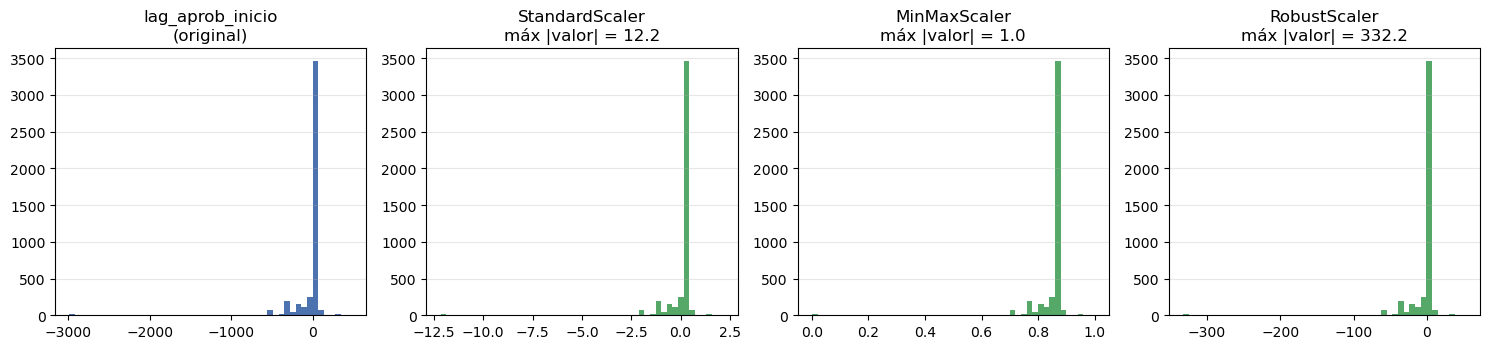

lag_aprob_inicio: IQR = 9 días · desviación típica = 242 · recorrido = 3467


In [28]:
# Cuatro paneles: la variable original y el resultado de cada escalador.
variable = "lag_aprob_inicio"
fig, ejes = plt.subplots(1, 4, figsize=(15, 3.6))

ejes[0].hist(X_tr[variable], bins=50, color="#4C72B0")
ejes[0].set_title(f"{variable}\n(original)")
for eje, (nombre, z) in zip(ejes[1:], escalados.items()):
    eje.hist(z[variable], bins=50, color="#55A868")
    eje.set_title(f"{nombre}\nmáx |valor| = {z[variable].abs().max():.1f}")
for eje in ejes:
    eje.grid(axis="y", alpha=.3)
plt.tight_layout()
fig.savefig(DIR_ANEXOS / "anexo_f4_escaladores.png", dpi=150, bbox_inches="tight")
plt.show()

q1, q3 = X_tr[variable].quantile([.25, .75])
print(f"{variable}: IQR = {q3 - q1:.0f} días · desviación típica = {X_tr[variable].std():.0f} "
      f"· recorrido = {X_tr[variable].max() - X_tr[variable].min():.0f}")

**Decisión: `StandardScaler`.** El resultado contradice la intuición habitual —que el escalador
robusto es preferible ante colas largas— y conviene entender por qué antes de aceptarlo.

`RobustScaler` divide por el rango intercuartílico, que en `lag_aprob_inicio` es de apenas
**9 días**, porque el grueso de los permisos empieza pocos días después de su aprobación. Pero
el recorrido completo de esa variable abarca **3.467 días**. Dividir ese recorrido por una escala
de 9 produce valores de hasta 332. `StandardScaler` divide por la desviación típica, de 242 días,
que sí absorbe las colas y deja el máximo en 14.

La lección no es que un escalador sea mejor que otro, sino que el divisor debe ser una medida de
dispersión **comparable al recorrido** de la variable. Aquí el rango intercuartílico no lo es.

*Enfoques descartados.* `RobustScaler`, por lo anterior: su máximo llega a 405 en prueba.
`MinMaxScaler` parece atractivo porque en entrenamiento nunca se sale de `[0, 1]`, pero eso es
trivial —el rango se fija precisamente con esos extremos—; en prueba deja fuera 206 valores. Y
sobre todo, su rango intercuartílico medio es de 0,22 frente a 0,91 del estándar: comprime el
cuerpo de la distribución en una franja estrecha para dejar sitio a las colas, que es justo lo
contrario de lo que interesa.

In [29]:
def verificar_escalamiento(valores, metodo, tol=1e-9):
    """
    Comprueba que un escalador produjo lo que su definicion promete.

    Retorna
    -------
    dict
        Metricas observadas y resultado de la comprobacion.

    Lanza
    -----
    ValueError
        Si el metodo no esta contemplado.
    """
    media, desv = float(np.mean(valores)), float(np.std(valores))
    minimo, maximo = float(np.min(valores)), float(np.max(valores))
    if metodo == "standard":
        ok = abs(media) < 1e-6 and abs(desv - 1) < 1e-6
        esperado = "media 0 y desviación 1"
    elif metodo == "minmax":
        ok = minimo >= -tol and maximo <= 1 + tol
        esperado = "valores dentro de [0, 1]"
    elif metodo == "robust":
        ok = abs(float(np.median(valores))) < 1e-6
        esperado = "mediana 0"
    else:
        raise ValueError(f"Método no contemplado: {metodo!r}")
    return {"metodo": metodo, "esperado": esperado, "media": round(media, 6),
            "desv": round(desv, 6), "min": round(minimo, 3), "max": round(maximo, 3),
            "cumple": "sí" if ok else "NO"}


df, escalador = escalar_caracteristicas(df, NUMERICAS, StandardScaler(), ajustar_en=es_train)

verificacion_esc = pd.DataFrame([
    verificar_escalamiento(df.loc[es_train, col], "standard") | {"variable": col}
    for col in NUMERICAS
])[["variable", "metodo", "esperado", "media", "desv", "cumple"]]
display(verificacion_esc)
assert (verificacion_esc.cumple == "sí").all(), "El escalamiento no cumple su definición."
print("[OK] Las cinco variables quedan con media 0 y desviación 1 en entrenamiento.")
print("El indicador binario tiene_proposito NO se escala: conserva sus valores 0 y 1.")

,variable,metodo,esperado,media,desv,cumple
0,n_segmentos,standard,media 0 y desviación 1,-0.0,1.0,sí
1,lag_aprob_inicio,standard,media 0 y desviación 1,-0.0,1.0,sí
2,anio_aprobacion,standard,media 0 y desviación 1,-0.0,1.0,sí
3,mes_inicio,standard,media 0 y desviación 1,0.0,1.0,sí
4,largo_proposito,standard,media 0 y desviación 1,-0.0,1.0,sí


[OK] Las cinco variables quedan con media 0 y desviación 1 en entrenamiento.
El indicador binario tiene_proposito NO se escala: conserva sus valores 0 y 1.


### Transformación del objetivo

La duración es fuertemente asimétrica. Se calcula la transformación logarítmica y se deja
**junto** al objetivo original, sin sustituirlo: cuál usar es una decisión de modelado que
corresponde a la Fase 3, y esta fase no debe cerrarla por ella.

In [30]:
df["duracion_log"] = np.log1p(df[OBJETIVO])

print(f"asimetría de {OBJETIVO:16}: {df[OBJETIVO].skew():6.2f}")
print(f"asimetría de duracion_log     : {df.duracion_log.skew():6.2f}")
print(f"valores distintos del objetivo: {df[OBJETIVO].nunique()} en {len(df)} filas")
print("\nEl logaritmo reduce la asimetría pero la sobrecorrige hacia la izquierda, efecto")
print("de las masas puntuales en duraciones cortas: la autoridad asigna las fechas de")
print("término por lotes. Se persisten ambas versiones.")

asimetría de duracion_dias   :   1.46
asimetría de duracion_log     :  -0.65
valores distintos del objetivo: 231 en 6010 filas

El logaritmo reduce la asimetría pero la sobrecorrige hacia la izquierda, efecto
de las masas puntuales en duraciones cortas: la autoridad asigna las fechas de
término por lotes. Se persisten ambas versiones.


## 6. Validación técnica y verificación del código

Todo lo afirmado se comprueba aquí. Si algo falla, el cuaderno se detiene y no persiste nada.

In [31]:
def validar_dataset(datos, grupos_one_hot=None, prohibidas=None, objetivo=None):
    """
    Comprueba integridad, consistencia y coherencia del dataset final.

    Extiende la comprobacion habitual con dos controles propios del proyecto: que
    ninguna variable prohibida se haya colado y que el objetivo no figure entre las
    caracteristicas.

    Lanza
    -----
    AssertionError
        Si alguna comprobacion falla.
    """
    print("VALIDACIÓN DEL DATASET FINAL")
    print("-" * 45)
    registro = []

    def anotar(texto, condicion, detalle=""):
        registro.append({"comprobacion": texto,
                         "resultado": "OK" if bool(condicion) else "FALLA",
                         "detalle": str(detalle)})
        assert condicion, f"{texto}: {detalle}"
        print(f"[OK] {texto}" + (f" ({detalle})" if detalle else ""))

    # 1. Integridad
    nulos = int(datos.isnull().sum().sum())
    anotar("Sin valores nulos", nulos == 0, f"total = {nulos}")

    # 2. Consistencia: todas las columnas son numericas
    no_num = datos.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()
    anotar("Todas las columnas son numéricas", not no_num, f"no numéricas: {no_num}")
    anotar("Sin valores infinitos",
           not np.isinf(datos.select_dtypes(include=[np.number]).to_numpy()).any())

    # 3. Coherencia: cada grupo one-hot suma 1 por fila
    if grupos_one_hot:
        for nombre, cols in grupos_one_hot.items():
            suma = datos[cols].sum(axis=1)
            anotar(f"Grupo one-hot '{nombre}' coherente", bool((suma == 1).all()),
                   f"{len(cols)} columnas")

    # 4. Control de fugas
    if prohibidas:
        coladas = [c for p in prohibidas for c in datos.columns if c.startswith(p)]
        anotar("Ninguna variable prohibida presente", not coladas, f"excluidas: {prohibidas}")
    if objetivo:
        anotar("El objetivo no está entre las características", objetivo not in datos.columns)

    # 5. Duplicados y dimensiones
    dup = int(datos.duplicated().sum())
    print(f"[INFO] Filas duplicadas: {dup}")
    print(f"[INFO] Dimensiones finales: {datos.shape}")
    return pd.DataFrame(registro)


COLUMNAS_INDICADORAS = [c for cols in grupos_one_hot.values() for c in cols]
CARACTERISTICAS = NUMERICAS + BINARIAS + COLUMNAS_INDICADORAS

tabla_validacion = validar_dataset(df[CARACTERISTICAS], grupos_one_hot,
                                   prohibidas=PROHIBIDAS, objetivo=OBJETIVO)

# Comprobaciones que dependen de la particion y del archivo original.
extra = []
extra.append({"comprobacion": "Sin permisos compartidos entre particiones",
              "resultado": "OK" if not (permisos_tr & permisos_te) else "FALLA",
              "detalle": f"{len(permisos_tr)} train / {len(permisos_te)} test"})
extra.append({"comprobacion": "Filas coinciden con lo declarado en la Fase 1",
              "resultado": "OK" if len(df) == META_F1["conjunto_trabajo"]["filas"] else "FALLA",
              "detalle": f"{len(df)} de {META_F1['conjunto_trabajo']['filas']}"})
extra.append({"comprobacion": "Archivo crudo no modificado",
              "resultado": "OK" if df_crudo.equals(cargar_datos(ARCHIVO)) else "FALLA",
              "detalle": ARCHIVO.name})
tabla_validacion = pd.concat([tabla_validacion, pd.DataFrame(extra)], ignore_index=True)

assert (tabla_validacion.resultado == "OK").all(), "Hay comprobaciones fallidas."
print(f"\n[OK] {len(tabla_validacion)}/{len(tabla_validacion)} comprobaciones superadas")
tabla_validacion

VALIDACIÓN DEL DATASET FINAL
---------------------------------------------
[OK] Sin valores nulos (total = 0)
[OK] Todas las columnas son numéricas (no numéricas: [])
[OK] Sin valores infinitos
[OK] Grupo one-hot 'tipo_permiso' coherente (11 columnas)
[OK] Grupo one-hot 'agente' coherente (13 columnas)
[OK] Grupo one-hot 'distrito' coherente (12 columnas)
[OK] Grupo one-hot 'inspector' coherente (14 columnas)
[OK] Grupo one-hot 'analysis_neighborhood' coherente (42 columnas)
[OK] Grupo one-hot 'permit_zipcode' coherente (30 columnas)
[OK] Ninguna variable prohibida presente (excluidas: ['Status', 'permit_start_date', 'permit_end_date'])
[OK] El objetivo no está entre las características
[INFO] Filas duplicadas: 3641
[INFO] Dimensiones finales: (6010, 128)

[OK] 14/14 comprobaciones superadas


,comprobacion,resultado,detalle
0,Sin valores nulos,OK,total = 0
1,Todas las columnas son numéricas,OK,no numéricas: []
2,Sin valores infinitos,OK,
3,Grupo one-hot 'tipo_permiso' coherente,OK,11 columnas
4,Grupo one-hot 'agente' coherente,OK,13 columnas
5,Grupo one-hot 'distrito' coherente,OK,12 columnas
6,Grupo one-hot 'inspector' coherente,OK,14 columnas
7,Grupo one-hot 'analysis_neighborhood' coherente,OK,42 columnas
8,Grupo one-hot 'permit_zipcode' coherente,OK,30 columnas
9,Ninguna variable prohibida presente,OK,"excluidas: ['Status', 'permit_start_date', 'pe..."


### Pruebas de las funciones (casos normal, límite y excepciones)

Cada función definida en este cuaderno se prueba con los tres tipos de caso. La salida se captura
para el Anexo G del informe.

In [32]:
def probar_funciones():
    """Pruebas de las funciones del cuaderno: casos normal, limite y excepciones."""
    prueba = pd.DataFrame({"color": ["rojo", "azul", "rojo", "verde"]})

    # --- codificar_one_hot ---
    salida, creadas = codificar_one_hot(prueba, "color", prefijo="c")
    assert creadas == ["c_azul", "c_rojo", "c_verde"]                      # normal
    assert (salida[creadas].sum(axis=1) == 1).all()                        # suma 1 por fila
    una, cols = codificar_one_hot(pd.DataFrame({"x": ["a"]}), "x")         # limite: 1 categoria
    assert len(cols) == 1 and una[cols[0]].iloc[0] == 1
    print("[OK] codificar_one_hot: caso normal y caso límite")
    try:
        codificar_one_hot(prueba, "inexistente")
        raise AssertionError("debió lanzar KeyError")
    except KeyError as e:
        print(f"[OK] codificar_one_hot lanza KeyError: {str(e)[:48]}...")
    try:
        codificar_one_hot(prueba, "color", nombres_columnas=["solo_uno"])
        raise AssertionError("debió lanzar ValueError")
    except ValueError as e:
        print(f"[OK] codificar_one_hot lanza ValueError: {str(e)[:48]}...")

    # --- detectar_atipicos_iqr ---
    assert detectar_atipicos_iqr(pd.Series([1, 1, 1, 1, 100]))["n"] == 1   # normal
    assert detectar_atipicos_iqr(pd.Series([], dtype=float))["n"] == 0     # limite: vacia
    print("[OK] detectar_atipicos_iqr: caso normal y serie vacía")
    try:
        detectar_atipicos_iqr(pd.Series([1, 2, 3]), factor=0)
        raise AssertionError("debió lanzar ValueError")
    except ValueError as e:
        print(f"[OK] detectar_atipicos_iqr lanza ValueError: {e}")

    # --- verificar_escalamiento ---
    z = np.array([1.0, 2.0, 3.0, 4.0])
    z = (z - z.mean()) / z.std()                                           # normal
    assert verificar_escalamiento(z, "standard")["cumple"] == "sí"
    assert verificar_escalamiento(np.array([0.0, 0.5, 1.0]), "minmax")["cumple"] == "sí"
    assert verificar_escalamiento(np.array([1.0, 2.0, 3.0]), "standard")["cumple"] == "NO"
    print("[OK] verificar_escalamiento: detecta el caso que cumple y el que no")
    try:
        verificar_escalamiento(np.array([0.0]), "inventado")
        raise AssertionError("debió lanzar ValueError")
    except ValueError as e:
        print(f"[OK] verificar_escalamiento lanza ValueError: {e}")

    # --- ImputadorMixto ---
    peq = df.loc[es_train].head(400)
    imp = ImputadorMixto(["permit_zipcode"], ["lag_aprob_inicio"]).fit(peq)
    assert imp.transform(peq).permit_zipcode.isna().sum() == 0             # normal
    vacio = peq.head(3).copy()
    vacio["permit_zipcode"] = np.nan
    vacio["lag_aprob_inicio"] = np.nan
    salida = imp.transform(vacio)                                          # limite
    assert (salida.permit_zipcode == "Desconocido").all()
    assert salida.lag_aprob_inicio.notna().all()
    print("[OK] ImputadorMixto: caso normal y columnas enteramente ausentes")
    try:
        ImputadorMixto(["inexistente"], []).fit(peq)
        raise AssertionError("debió lanzar KeyError")
    except KeyError as e:
        print(f"[OK] ImputadorMixto lanza KeyError: {str(e)[:48]}...")
    try:
        ImputadorMixto(["permit_zipcode"], []).transform(peq)
        raise AssertionError("debió lanzar RuntimeError")
    except RuntimeError as e:
        print(f"[OK] ImputadorMixto lanza RuntimeError: {e}")

    # --- comparar_imputaciones y cargar_datos ---
    try:
        comparar_imputaciones(peq, ["permit_zipcode"], fraccion=1.5)
        raise AssertionError("debió lanzar ValueError")
    except ValueError as e:
        print(f"[OK] comparar_imputaciones lanza ValueError: {e}")
    try:
        cargar_datos("archivo_que_no_existe_12345.csv")
        raise AssertionError("debió lanzar FileNotFoundError")
    except FileNotFoundError as e:
        print(f"[OK] cargar_datos lanza FileNotFoundError: {str(e)[:48]}...")

    print("\n[OK] 17/17 pruebas superadas")
    return True


_, ANEXO_G2 = capturar(probar_funciones)      # Anexo G del informe (Fase 2)

[OK] codificar_one_hot: caso normal y caso límite
[OK] codificar_one_hot lanza KeyError: "La columna 'inexistente' no existe."...
[OK] codificar_one_hot lanza ValueError: Se esperaban 3 nombres y llegaron 1....
[OK] detectar_atipicos_iqr: caso normal y serie vacía
[OK] detectar_atipicos_iqr lanza ValueError: El factor debe ser positivo.
[OK] verificar_escalamiento: detecta el caso que cumple y el que no
[OK] verificar_escalamiento lanza ValueError: Método no contemplado: 'inventado'
[OK] ImputadorMixto: caso normal y columnas enteramente ausentes
[OK] ImputadorMixto lanza KeyError: "Columnas ausentes: ['inexistente']"...
[OK] ImputadorMixto lanza RuntimeError: Llame a fit antes de transform.
[OK] comparar_imputaciones lanza ValueError: fraccion debe estar entre 0 y 1
[OK] cargar_datos lanza FileNotFoundError: No se encontro el archivo archivo_que_no_existe_...

[OK] 17/17 pruebas superadas


### Visualización de control

Dos gráficos que sostienen afirmaciones del informe: la forma del objetivo y su relación con el
factor dominante. *(Figuras del Anexo F.)*

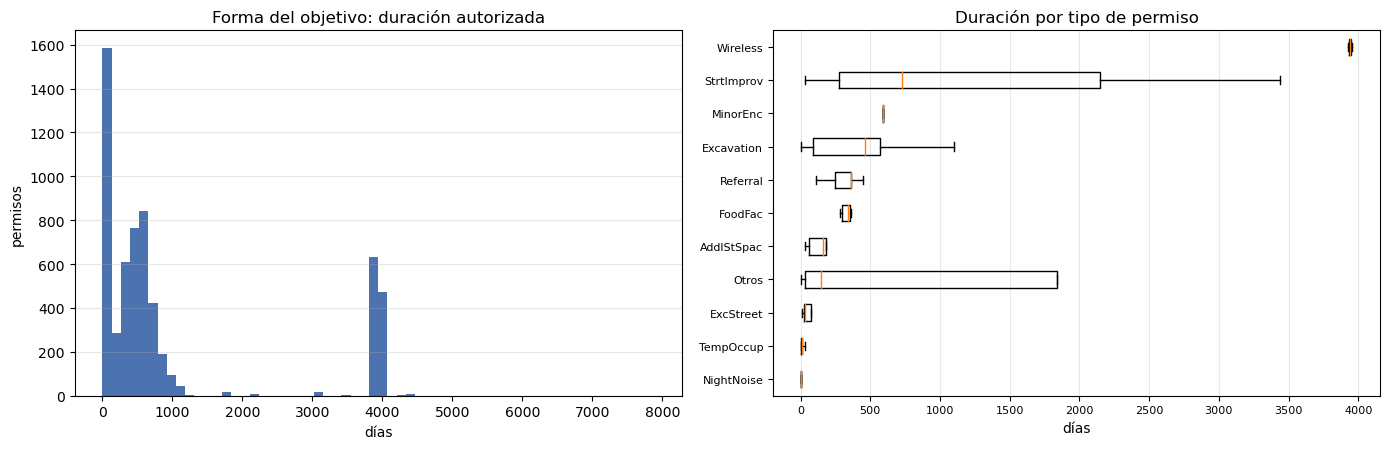

Figuras del Anexo F guardadas en docs/anexos


In [33]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))

# (1) Forma del objetivo: justifica evaluar una transformacion.
ejes[0].hist(df[OBJETIVO], bins=60, color="#4C72B0")
ejes[0].set_title("Forma del objetivo: duración autorizada")
ejes[0].set_xlabel("días"); ejes[0].set_ylabel("permisos"); ejes[0].grid(axis="y", alpha=.3)

# (2) El factor dominante segun la Fase 1.
orden = df.groupby("tipo_permiso")[OBJETIVO].median().sort_values().index
ejes[1].boxplot([df.loc[df.tipo_permiso == t, OBJETIVO] for t in orden],
                labels=list(orden), vert=False, showfliers=False)
ejes[1].set_title("Duración por tipo de permiso")
ejes[1].set_xlabel("días"); ejes[1].grid(axis="x", alpha=.3); ejes[1].tick_params(labelsize=8)

plt.tight_layout()
fig.savefig(DIR_ANEXOS / "anexo_f1_forma_objetivo.png", dpi=150, bbox_inches="tight")
plt.show()

# La segunda figura tambien por separado, para poder insertarla sola en el informe.
fig2, eje2 = plt.subplots(figsize=(8, 5))
eje2.boxplot([df.loc[df.tipo_permiso == t, OBJETIVO] for t in orden],
             labels=list(orden), vert=False, showfliers=False)
eje2.set_title("Duración autorizada por tipo de permiso")
eje2.set_xlabel("días"); eje2.grid(axis="x", alpha=.3)
plt.tight_layout()
fig2.savefig(DIR_ANEXOS / "anexo_f2_duracion_por_tipo.png", dpi=150, bbox_inches="tight")
plt.close(fig2)

print("Figuras del Anexo F guardadas en", DIR_ANEXOS.relative_to(RAIZ).as_posix())

In [34]:
print("Dataset final:", df.shape)
print(f"  características : {len(CARACTERISTICAS)} "
      f"({len(NUMERICAS)} numéricas + {len(BINARIAS)} binaria + "
      f"{len(COLUMNAS_INDICADORAS)} indicadoras)")
print(f"  objetivo        : {OBJETIVO} y su transformación duracion_log")
print(f"  claves          : {GRUPO_VAR}, particion")
df[CARACTERISTICAS[:6] + [OBJETIVO, "particion"]].head()

Dataset final: (6010, 150)
  características : 128 (5 numéricas + 1 binaria + 122 indicadoras)
  objetivo        : duracion_dias y su transformación duracion_log
  claves          : permit_number, particion


,n_segmentos,lag_aprob_inicio,anio_aprobacion,mes_inicio,largo_proposito,tiene_proposito,duracion_dias,particion
0,0.036761,0.252458,0.543681,-0.628404,0.585092,1,180.0,test
1,0.380170,0.198726,0.247535,0.047062,3.198095,1,587.0,test
2,0.380170,0.198726,0.247535,0.047062,3.198095,1,587.0,test
3,0.380170,0.198726,0.247535,0.047062,3.198095,1,587.0,test
4,0.380170,0.198726,0.247535,0.047062,3.198095,1,587.0,test


## Conclusiones y trazabilidad

La fase deja un conjunto validado y dos archivos con propósitos distintos alineados con nuestra revisión de los objetivos de la asignatura: uno interpretable para
el análisis y los gráficos de la Fase 4, y otro codificado y escalado para el modelado de la
Fase 3. Cada paso se implementó como una función documentada y probada: `cargar_datos`,
`explorar_dataframe`, `detectar_atipicos_iqr`, `comparar_imputaciones`, `codificar_one_hot`,
`escalar_caracteristicas`, `verificar_escalamiento`, `validar_dataset` y la clase
`ImputadorMixto`.

**Trazabilidad con el repositorio (F2):** este cuaderno se ubica en `F2/`; lee el contrato que la
Fase 1 dejó en `docs/`, escribe sus salidas en `data/processed/` y `src/`, y genera en
`docs/anexos/` las figuras y las salidas de prueba que el informe cita como anexos.

**Tres decisiones que se apartan de la guía, y por qué.** La partición se hace antes de ajustar
cualquier transformador, en lugar de solo advertir sobre la fuga. Las decisiones sobre qué
variable es el objetivo se leen de la Fase 1 en lugar de repetirse. Y la limpieza se contrasta
contra la función del módulo compartido, de modo que dos caminos independientes deban coincidir.

## 7. Recursividad: aplanar los metadatos del proyecto

Los metadatos del proyecto tienen estructura **anidada**: un diccionario que contiene
diccionarios, a profundidad desconocida de antemano. Para escribirlos como tabla en el informe
hace falta convertirlos en pares clave-valor de un solo nivel.

Es el caso natural de una función recursiva: el problema de aplanar un diccionario se resuelve
aplanando cada uno de sus valores que a su vez sea un diccionario. La función se llama a sí
misma un nivel más abajo hasta llegar a un valor simple, que es el **caso base**.

In [35]:
# Los metadatos de esta fase, con la estructura anidada que les corresponde.
METADATOS = {
    "proyecto": {
        "nombre": "Factores asociados a la duración autorizada de permisos de vía pública",
        "grupo": "Grupo 5",
        "fase": "F2",
        "semilla": SEMILLA,
        "fecha_ejecucion": date.today().isoformat(),
    },
    "datos": {
        "archivo": FUENTE["archivo"],
        "corte": FUENTE["corte_declarado"],
        "filas": int(len(df)),
        "fuente": {
            "plataforma": FUENTE["plataforma"],
            "autor": FUENTE["autor"],
            "licencia": FUENTE["licencia"],
            "url": FUENTE["url"],
        },
    },
    "decisiones": {
        "particion": {"esquema": f"por {GRUPO_VAR} (GroupShuffleSplit)",
                      "test_size": 0.25,
                      "permisos_train": len(permisos_tr),
                      "permisos_test": len(permisos_te)},
        "imputacion": {"categoricas": "categoría explícita 'Desconocido'",
                       "numericas": "mediana de entrenamiento"},
        "escalador": "StandardScaler",
        "codificacion": "OneHotEncoder(handle_unknown='ignore')",
        "atipicos": "no se eliminan; las colas son reales",
        "nominales": NOMINALES,
        "numericas": NUMERICAS,
    },
    "objetivo": {"principal": OBJETIVO, "transformado": "duracion_log (log1p)"},
    "excluidas_por_fuga": PROHIBIDAS,
}


def aplanar(estructura, prefijo="", separador="."):
    """
    Aplana un diccionario anidado en uno de un solo nivel.

    Parametros
    ----------
    estructura : dict
        Diccionario, posiblemente anidado a cualquier profundidad.
    prefijo : str
        Ruta acumulada desde la raiz. Uso interno de la recursion.
    separador : str
        Caracter que une los niveles de la ruta.

    Retorna
    -------
    dict
        Pares ruta -> valor, sin anidamiento.

    Ejemplo
    -------
    >>> aplanar({"a": {"b": 1, "c": {"d": 2}}})
    {'a.b': 1, 'a.c.d': 2}
    """
    plano = {}
    for clave, valor in estructura.items():
        # Se construye la ruta completa: en el primer nivel no hay prefijo.
        ruta = f"{prefijo}{separador}{clave}" if prefijo else str(clave)

        if isinstance(valor, dict):
            # CASO RECURSIVO: la funcion se llama a si misma un nivel mas abajo.
            plano.update(aplanar(valor, ruta, separador))
        elif isinstance(valor, (list, tuple)):
            # Las secuencias se convierten en texto legible para la tabla.
            plano[ruta] = ", ".join(str(v) for v in valor)
        else:
            # CASO BASE: el valor es simple y se devuelve el par tal cual.
            plano[ruta] = valor
    return plano


metadatos_planos = aplanar(METADATOS)
print(f"El diccionario anidado se aplanó en {len(metadatos_planos)} pares.\n")
for clave, valor in metadatos_planos.items():
    print(f"  {clave:<34} {str(valor)[:56]}")

El diccionario anidado se aplanó en 26 pares.

  proyecto.nombre                    Factores asociados a la duración autorizada de permisos 
  proyecto.grupo                     Grupo 5
  proyecto.fase                      F2
  proyecto.semilla                   42
  proyecto.fecha_ejecucion           2026-09-16
  datos.archivo                      Active_Street-Use_Permits_20260909.csv
  datos.corte                        2026-09-09
  datos.filas                        6010
  datos.fuente.plataforma            DataSF
  datos.fuente.autor                 San Francisco Public Works
  datos.fuente.licencia              Open Data Commons Public Domain Dedication and License (
  datos.fuente.url                   https://data.sf.gov/City-Infrastructure/Active-Street-Us
  decisiones.particion.esquema       por permit_number (GroupShuffleSplit)
  decisiones.particion.test_size     0.25
  decisiones.particion.permisos_train 1604
  decisiones.particion.permisos_test 535
  decisiones.imputacion

In [36]:
# Verificación de la función recursiva: casos normal, profundo y límite.
assert aplanar({"a": 1}) == {"a": 1}, "Caso plano"
assert aplanar({"a": {"b": 1}}) == {"a.b": 1}, "Un nivel de anidamiento"
assert aplanar({"a": {"b": {"c": {"d": 4}}}}) == {"a.b.c.d": 4}, "Anidamiento profundo"
assert aplanar({}) == {}, "Caso límite: diccionario vacío"
assert aplanar({"x": [1, 2, 3]}) == {"x": "1, 2, 3"}, "Listas convertidas a texto"
assert aplanar({"a": {"b": 1}}, separador="/") == {"a/b": 1}, "Separador configurable"
print("[OK] La función recursiva pasa las seis pruebas.")

# La tabla aplanada es directamente publicable en el informe.
tabla_metadatos = pd.DataFrame(sorted(metadatos_planos.items()),
                               columns=["clave", "valor"])
tabla_metadatos.head(8)

[OK] La función recursiva pasa las seis pruebas.


,clave,valor
0,datos.archivo,Active_Street-Use_Permits_20260909.csv
1,datos.corte,2026-09-09
2,datos.filas,6010
3,datos.fuente.autor,San Francisco Public Works
4,datos.fuente.licencia,Open Data Commons Public Domain Dedication and...
5,datos.fuente.plataforma,DataSF
6,datos.fuente.url,https://data.sf.gov/City-Infrastructure/Active...
7,decisiones.atipicos,no se eliminan; las colas son reales


> **Cuándo NO usar recursividad.** Si la profundidad se conoce y es fija, un par de bucles
> anidados es más simple de leer y más rápido. La recursión gana cuando la profundidad es
> **desconocida de antemano**, que es exactamente el caso aquí: los metadatos crecerán en las
> fases siguientes y nadie sabe hoy cuántos niveles tendrán. Conviene además recordar que Python
> limita la profundidad de recursión —alrededor de mil llamadas—, de modo que no es la
> herramienta adecuada para estructuras arbitrariamente profundas.